# JSBSim Flight Simulation

This notebook demonstrates a trimmed flight simulation with the **Cessna 172P** using the
[JSBSim](https://github.com/JSBSim-Team/jsbsim) Python API.  We record a set of key flight
parameters over a 60-second time window and visualise them as time-history plots.

## Topics covered

* Running a longer simulation loop with data collection.
* Working with JSBSim's property tree (positions, velocities, attitudes, forces).
* Unit conversions (feet → metres, knots → m/s, radians → degrees).
* Producing publication-quality plots with `matplotlib`.

## 1. Setup

In [1]:
# If running on Google Colab, install the required packages.

import sys

if 'google.colab' in sys.modules:
    print('Running on Google Colab \u2013 installing jsbsim \u2026')
    !pip install jsbsim

In [2]:
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import jsbsim

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.4,
})

print(f"JSBSim version : {jsbsim.__version__}")
print(f"NumPy version  : {np.__version__}")
print(f"Matplotlib ver : {matplotlib.__version__}")

JSBSim version : 1.3.0
NumPy version  : 2.4.4
Matplotlib ver : 3.10.8


## 2. Initialise JSBSim and trim

In [3]:
# ---------- configuration ----------
AIRCRAFT      = 'c172p'
ALT_FT        = 5000.0   # Initial altitude [ft MSL]
AIRSPEED_KTS  = 90.0     # Calibrated airspeed [kts]
HEADING_DEG   = 90.0     # True heading [deg]
SIM_DURATION  = 60.0     # Simulation duration [s]
RECORD_HZ     = 10       # Data recording frequency [Hz]
# -----------------------------------

fdm = jsbsim.FGFDMExec(None)
fdm.set_debug_level(0)
fdm.load_model(AIRCRAFT)

fdm['ic/h-sl-ft']      = ALT_FT
fdm['ic/vc-kts']       = AIRSPEED_KTS
fdm['ic/gamma-deg']    = 0.0
fdm['ic/psi-true-deg'] = HEADING_DEG
fdm.run_ic()

fdm['propulsion/set-running'] = -1
fdm['simulation/do_simple_trim'] = 1

dt          = fdm.get_delta_t()
record_step = max(1, int(1.0 / (RECORD_HZ * dt)))

print(f"Aircraft       : {AIRCRAFT}")
print(f"Alt (MSL)      : {ALT_FT:.0f} ft")
print(f"Airspeed       : {AIRSPEED_KTS:.0f} kts KCAS")
print(f"Time step Δt   : {dt:.6f} s  ({1/dt:.0f} Hz)")
print(f"Record step    : every {record_step} steps ({RECORD_HZ} Hz)")
print(f"Trim AoA       : {fdm['aero/alpha-deg']:.2f} deg")
print(f"Trim throttle  : {fdm['fcs/throttle-cmd-norm[0]']:.3f}")



     JSBSim Flight Dynamics Model v1.3.0 Apr  9 2026 10:00:08
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Aircraft       : c172p
Alt (MSL)      : 5000 ft
Airspeed       : 90 kts KCAS
Time step Δt   : 0.008333 s  (120 Hz)
Record step    : every 12 steps (10 Hz)
Trim AoA       : 1.28 deg
Trim throttle  : 0.694


## 3. Run the simulation and record data

In [4]:
# Containers for recorded data
rec = {
    't_s':        [],
    'alt_ft':     [],
    'alt_m':      [],
    'vt_fps':     [],
    'vc_kts':     [],
    'alpha_deg':  [],
    'theta_deg':  [],
    'phi_deg':    [],
    'psi_deg':    [],
    'nx':         [],   # load factor (longitudinal)
    'nz':         [],   # load factor (normal)
    'lat_deg':    [],
    'lon_deg':    [],
}

total_steps = int(SIM_DURATION / dt)
step = 0

while step < total_steps:
    fdm.run()
    step += 1

    if step % record_step == 0:
        rec['t_s'].append(fdm['simulation/sim-time-sec'])
        rec['alt_ft'].append(fdm['position/h-sl-ft'])
        rec['alt_m'].append(fdm['position/h-sl-ft'] * 0.3048)
        rec['vt_fps'].append(fdm['velocities/vt-fps'])
        rec['vc_kts'].append(fdm['velocities/vc-kts'])
        rec['alpha_deg'].append(fdm['aero/alpha-deg'])
        rec['theta_deg'].append(fdm['attitude/theta-deg'])
        rec['phi_deg'].append(fdm['attitude/phi-deg'])
        rec['psi_deg'].append(fdm['attitude/psi-deg'])
        rec['nx'].append(fdm['accelerations/Nx'])
        rec['nz'].append(fdm['accelerations/Nz'])
        rec['lat_deg'].append(math.degrees(fdm['position/lat-geod-rad']))
        rec['lon_deg'].append(math.degrees(fdm['position/long-gc-rad']))

# Convert to NumPy arrays for convenient indexing
for key in rec:
    rec[key] = np.array(rec[key])

print(f"Recorded {len(rec['t_s'])} samples over {SIM_DURATION:.0f} s")
print(f"Final altitude : {rec['alt_ft'][-1]:.1f} ft")
print(f"Final airspeed : {rec['vc_kts'][-1]:.1f} kts KCAS")

Recorded 600 samples over 60 s
Final altitude : 5000.2 ft
Final airspeed : 90.0 kts KCAS


## 4. Visualise – altitude and airspeed

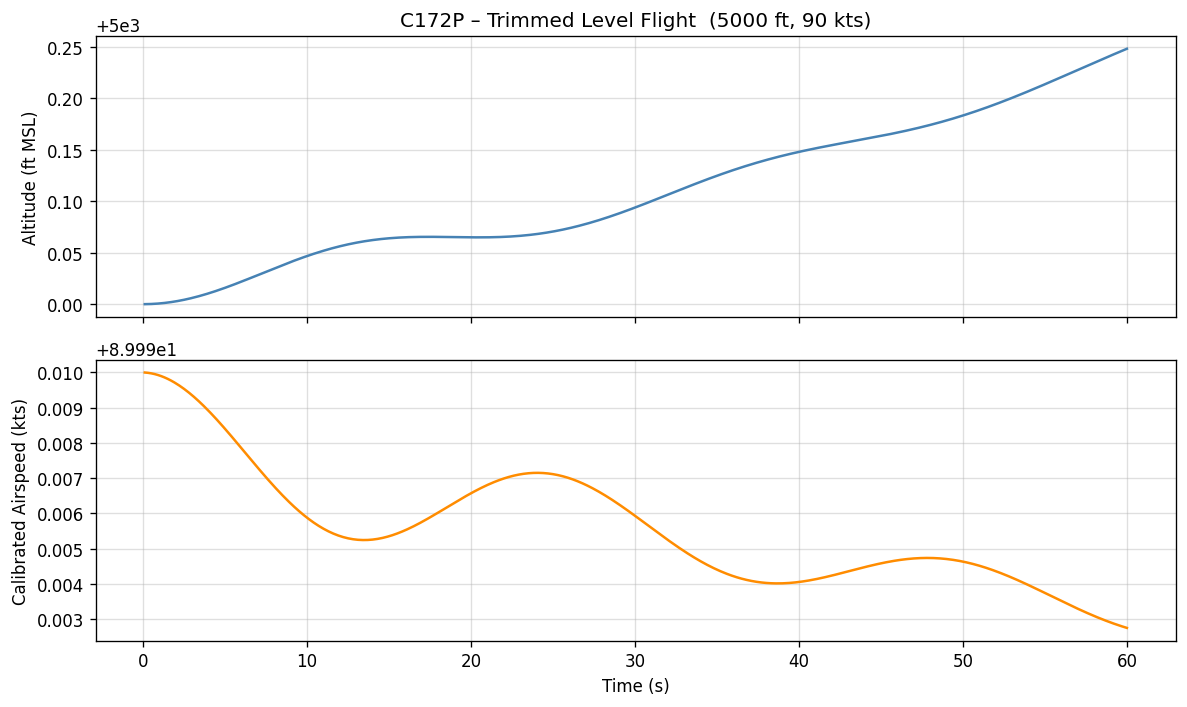

Figure saved as altitude_airspeed.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(rec['t_s'], rec['alt_ft'], color='steelblue', linewidth=1.5)
axes[0].set_ylabel('Altitude (ft MSL)')
axes[0].set_title(f'{AIRCRAFT.upper()} – Trimmed Level Flight  '
                  f'({ALT_FT:.0f} ft, {AIRSPEED_KTS:.0f} kts)')

axes[1].plot(rec['t_s'], rec['vc_kts'], color='darkorange', linewidth=1.5)
axes[1].set_ylabel('Calibrated Airspeed (kts)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('altitude_airspeed.png', bbox_inches='tight')
plt.show()
print("Figure saved as altitude_airspeed.png")

## 5. Visualise – attitude angles

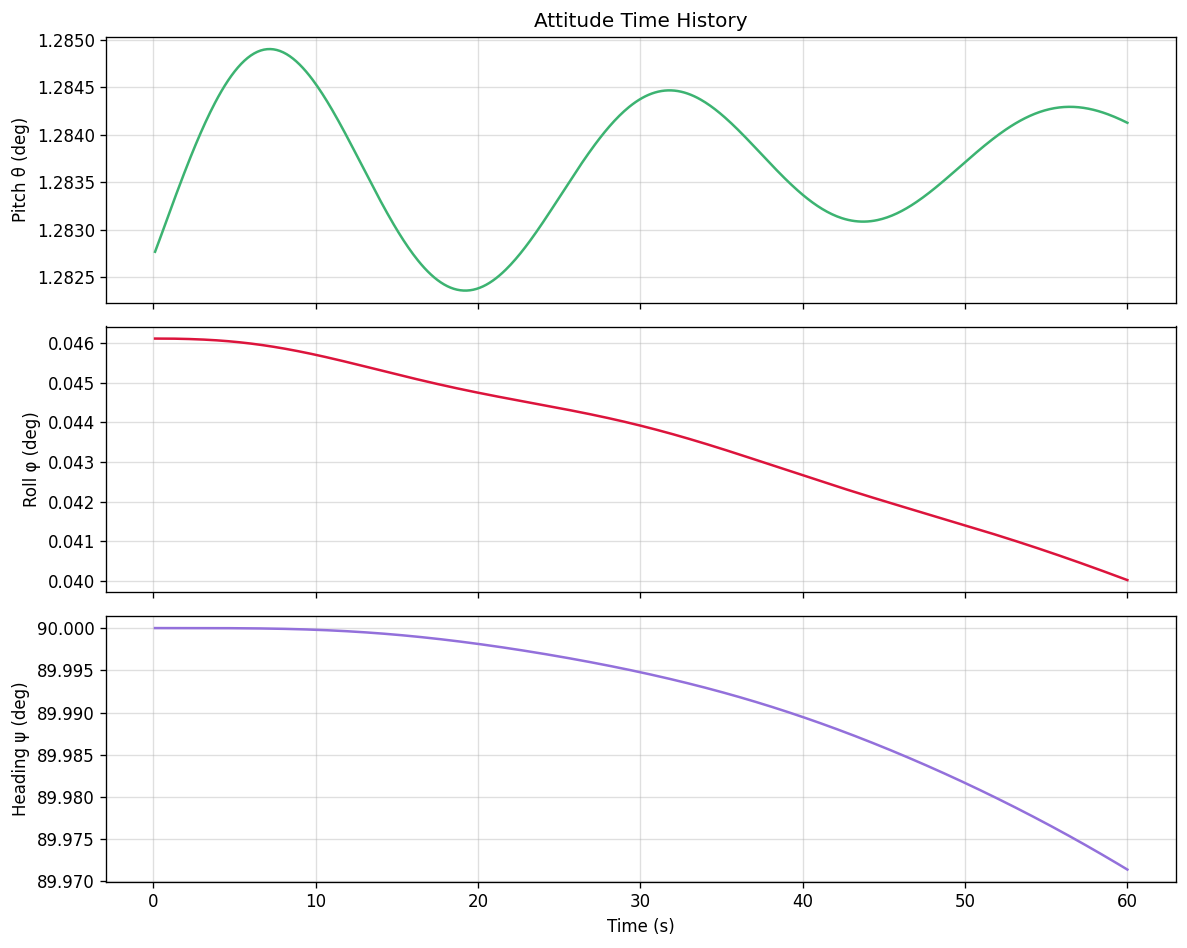

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(rec['t_s'], rec['theta_deg'], color='mediumseagreen', linewidth=1.5)
axes[0].set_ylabel('Pitch θ (deg)')
axes[0].set_title('Attitude Time History')

axes[1].plot(rec['t_s'], rec['phi_deg'], color='crimson', linewidth=1.5)
axes[1].set_ylabel('Roll φ (deg)')

axes[2].plot(rec['t_s'], rec['psi_deg'], color='mediumpurple', linewidth=1.5)
axes[2].set_ylabel('Heading ψ (deg)')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('attitude.png', bbox_inches='tight')
plt.show()

## 6. Visualise – ground track

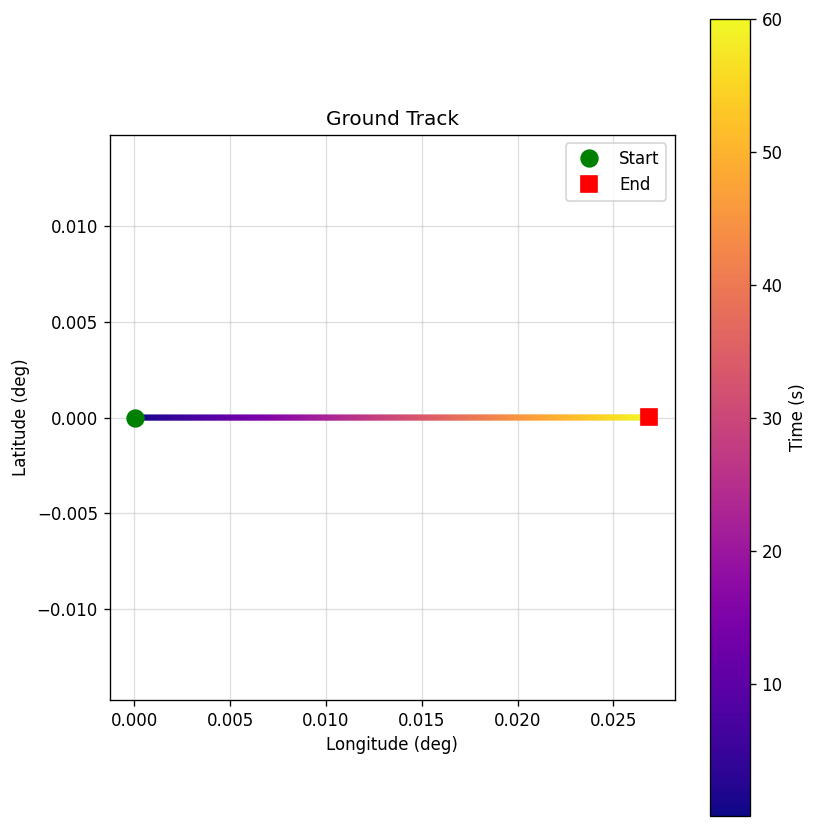

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

sc = ax.scatter(
    rec['lon_deg'], rec['lat_deg'],
    c=rec['t_s'], cmap='plasma', s=6, zorder=3
)
cbar = fig.colorbar(sc, ax=ax, label='Time (s)')

ax.plot(rec['lon_deg'][0], rec['lat_deg'][0],
        'go', ms=10, label='Start', zorder=4)
ax.plot(rec['lon_deg'][-1], rec['lat_deg'][-1],
        'rs', ms=10, label='End', zorder=4)

ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
ax.set_title('Ground Track')
ax.legend()

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
span = max(x_max - x_min, y_max - y_min)
x_center = 0.5 * (x_min + x_max)
y_center = 0.5 * (y_min + y_max)
ax.set_xlim(x_center - 0.5 * span, x_center + 0.5 * span)
ax.set_ylim(y_center - 0.5 * span, y_center + 0.5 * span)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('ground_track.png', bbox_inches='tight')
plt.show()

## 7. Reset and re-run: 10-degree turn to the left

JSBSim can be reset and re-trimmed to explore different manoeuvres.  Here we
apply a step aileron input to initiate a gentle left turn.

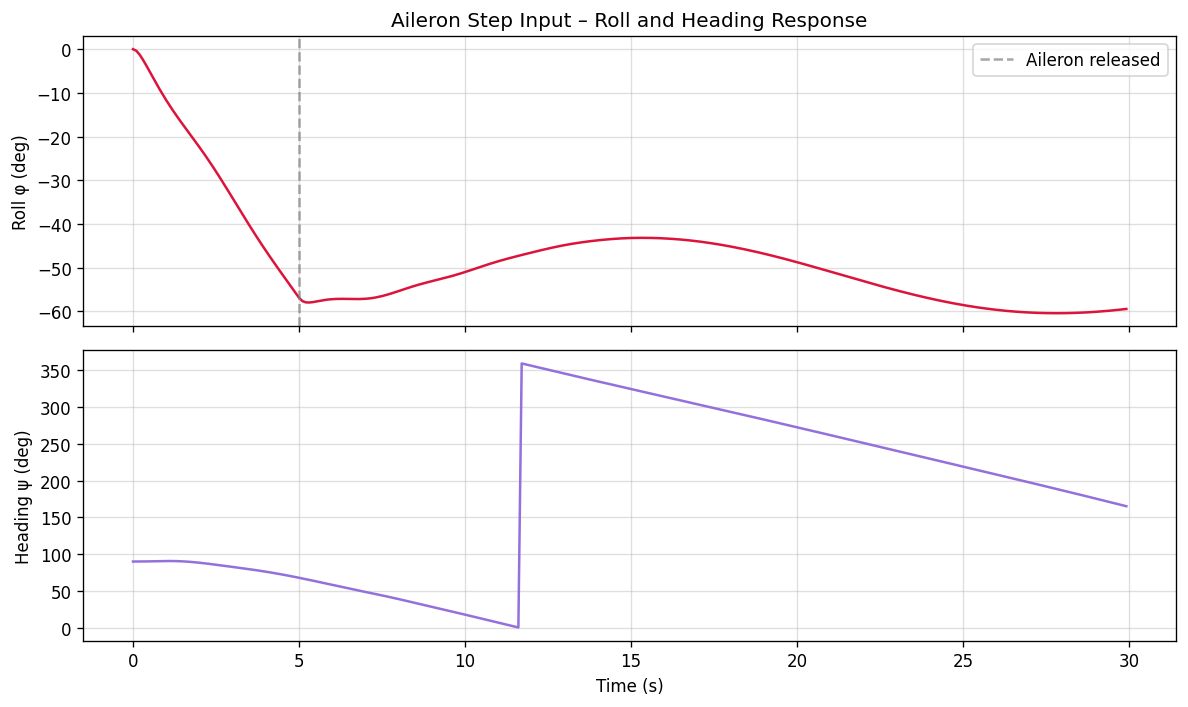

Turn manoeuvre complete


In [8]:
# Reset
fdm.reset_to_initial_conditions(0)
fdm['propulsion/set-running'] = -1
fdm['simulation/do_simple_trim'] = 1

turn_rec = {'t_s': [], 'phi_deg': [], 'psi_deg': [], 'alt_ft': []}

total_steps = int(30.0 / dt)
for step in range(total_steps):
    # Apply a gentle left aileron deflection for the first 5 s
    if fdm['simulation/sim-time-sec'] < 5.0:
        fdm['fcs/aileron-cmd-norm'] = -0.15
    else:
        fdm['fcs/aileron-cmd-norm'] = 0.0

    fdm.run()

    if step % record_step == 0:
        turn_rec['t_s'].append(fdm['simulation/sim-time-sec'])
        turn_rec['phi_deg'].append(fdm['attitude/phi-deg'])
        turn_rec['psi_deg'].append(fdm['attitude/psi-deg'])
        turn_rec['alt_ft'].append(fdm['position/h-sl-ft'])

for key in turn_rec:
    turn_rec[key] = np.array(turn_rec[key])

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(turn_rec['t_s'], turn_rec['phi_deg'], color='crimson', linewidth=1.5)
axes[0].axvline(5.0, linestyle='--', color='grey', alpha=0.7, label='Aileron released')
axes[0].set_ylabel('Roll φ (deg)')
axes[0].set_title('Aileron Step Input – Roll and Heading Response')
axes[0].legend()

axes[1].plot(turn_rec['t_s'], turn_rec['psi_deg'], color='mediumpurple', linewidth=1.5)
axes[1].set_ylabel('Heading ψ (deg)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('turn_manoeuvre.png', bbox_inches='tight')
plt.show()
print("Turn manoeuvre complete")

## Summary

In this notebook you:

* Ran a 60-second trimmed level-flight simulation.
* Recorded and plotted altitude, airspeed, attitude, and ground track.
* Demonstrated how to apply control inputs (aileron step) and observe the aircraft's response.

**Next:** [03_pathsim_intro.ipynb](03_pathsim_intro.ipynb) – introduction to PathSim.